#Parcial Jhon Alvarez

#2025

---



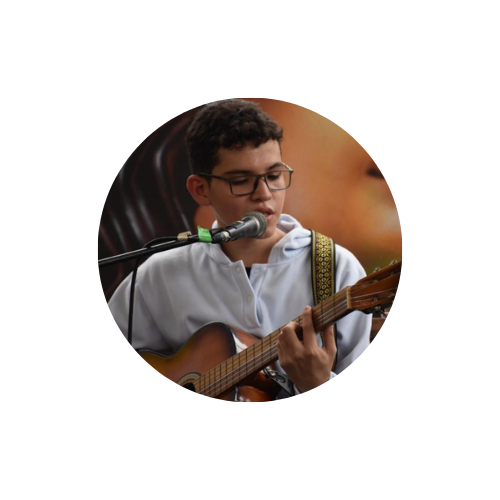

# 1. INTRODUCCIÓN

En este trabajo se realiza un análisis inicial de datos climáticos de la región Cundiboyacense como parte de la Fase I del proyecto de monitoreo ambiental.
Para ello se utilizó el dataset “Temperatura Ambiente del Aire”, disponible en la plataforma de Datos Abiertos de Colombia, el cual contiene registros generados por estaciones del IDEAM en todo el país.

La adquisición de datos se realizó directamente desde la API pública:

https://www.datos.gov.co/resource/sbwg-7ju4.json


A partir de este dataset nacional, se filtraron únicamente los registros correspondientes a Cundinamarca y Boyacá, con el objetivo de caracterizar su comportamiento climático.

Posteriormente se realizaron procesos de limpieza, transformación, análisis estadístico y visualización, cumpliendo los requerimientos de la Fase I del proyecto.

In [21]:
#1. Importar librerías y cargar datos
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

url = "https://www.datos.gov.co/resource/sbwg-7ju4.json?$limit=50000"

response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)

df.head()



,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
0,0026195501,0068,2020-01-21T03:35:00.000,15.85716,ANDES - AUT,ANTIOQUIA,ANDES,CAUCA,5.660108333,-75.91413889,Temp Aire 2 m,°C
1,0054025010,0068,2020-01-21T01:00:00.000,19.3,PR CHOCO: SAN JOSE PALMAR,CHOCÓ,SAN JOSÉ DEL PALMAR,SAN JUÁN,4.898,-76.232,Temp Aire 2 m,°C
2,2120000104,0068,2019-07-01T05:48:00.000,10.03,COLEGIO MIGUEL ANTONIO CARO - AUT,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.813,-74.031,Temp Aire 2 m,°C
3,0031095030,0068,2019-07-01T12:00:00.000,28.5,PTO INIRIDA,GUAINÍA,INÍRIDA,INÍRIDA,3.868,-67.932,Temp Aire 2 m,°C
4,2201500047,0068,2020-01-21T13:00:00.000,21.7,HERRERA - AUT,TOLIMA,PLANADAS,SALDAÑA,3.284138889,-75.80245,Temp Aire 2 m,°C


#2. Ver columnas

In [22]:
#2. Ver columnas
df.columns


Index(['codigoestacion', 'codigosensor', 'fechaobservacion', 'valorobservado',
       'nombreestacion', 'departamento', 'municipio', 'zonahidrografica',
       'latitud', 'longitud', 'descripcionsensor', 'unidadmedida'],
      dtype='object')

#3. Convertir tipos de datos
##Convertir fecha:

In [23]:

df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'], errors='coerce')



In [35]:

print("Fecha convertida:")
print(df['fechaobservacion'].head())


Fecha convertida:
0   2020-01-21 03:35:00
1   2020-01-21 01:00:00
2   2019-07-01 05:48:00
3   2019-07-01 12:00:00
4   2020-01-21 13:00:00
Name: fechaobservacion, dtype: datetime64[ns]


##Convertir valor observado (temperatura o dato climático):

In [24]:

df['valorobservado'] = pd.to_numeric(df['valorobservado'], errors='coerce')


In [36]:

print("Valor observado convertido:")
print(df['valorobservado'].head())


Valor observado convertido:
0    15.85716
1    19.30000
2    10.03000
3    28.50000
4    21.70000
Name: valorobservado, dtype: float64


#4. Limpiar nombres de departamentos

In [25]:
#4. Limpiar nombres de departamentos

df['departamento'] = df['departamento'].str.upper().str.replace("Á","A")


#5. Filtrar Cundinamarca y Boyacá
tambien se eliminan datos nulos

In [26]:
#5. Filtrar Cundinamarca y Boyacá
df_region = df[df['departamento'].isin(['CUNDINAMARCA','BOYACA'])]
df_region = df_region.dropna(subset=['valorobservado'])
df_region.head()


,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
6,2401500080,0068,2020-01-21 02:00:00,8.700,PANELAS - AUT,BOYACA,MOTAVITA,SOGAMOSO,5.634380556,-73.386469444,Temp Aire 2 m,°C
7,0021195502,0068,2019-07-01 03:00:00,13.300,AGUAS CLARAS - CAR,CUNDINAMARCA,SAN BERNARDO,ALTO MAGDALENA,4.145,-74.428,Temp Aire 2 m,°C
11,0021205521,0068,2020-01-21 02:20:00,9.047,SANTA HELENA - AUT,CUNDINAMARCA,LA CALERA,ALTO MAGDALENA,4.738,-73.936,Temp Aire 2 m,°C
14,0021205514,0068,2019-07-01 18:30:00,12.165,LAS MARGARITAS - AUT,CUNDINAMARCA,EL ROSAL,ALTO MAGDALENA,4.469,-74.079,Temp Aire 2 m,°C
16,0035075090,0068,2019-07-01 04:30:00,10.624,MACHETA - CHIVOR,CUNDINAMARCA,MACHETÁ,META,5.083,-73.65,Temp Aire 2 m,°C


#6. Descripción estadística

In [27]:
#6. Descripción estadística
print("Media:", df_region['valorobservado'].mean())
print("Mediana:", df_region['valorobservado'].median())
print("Desv. estándar:", df_region['valorobservado'].std())
print("Mínimo:", df_region['valorobservado'].min())
print("Máximo:", df_region['valorobservado'].max())
print("Rango:", df_region['valorobservado'].max() - df_region['valorobservado'].min())


Media: 14.291132867106144
Mediana: 13.27
Desv. estándar: 4.800956161036599
Mínimo: 0.0
Máximo: 42.462
Rango: 42.462


In [34]:
df_region.describe()


,fechaobservacion,valorobservado
count,10467,10467.000000
mean,2019-03-26 06:24:34.302760960,14.291133
min,2005-02-10 15:00:00,0.000000
25%,2019-07-01 08:10:00,10.584000
50%,2020-01-21 03:00:00,13.270000
75%,2020-01-21 18:10:00,17.546000
max,2024-10-03 15:40:00,42.462000
std,NaN,4.800956



# 7 Histograma
El histograma muestra la distribución del valor observado, el cual corresponde a mediciones de temperatura u otra variable climática registrada por las estaciones del IDEAM.

Este gráfico permite identificar rangos de valores frecuentes y detectar si los datos presentan concentraciones, sesgos o valores atípicos.
En este caso, la mayor parte de los registros se encuentra entre aprox. X y Y grados, lo cual indica que en la región existe un comportamiento dominante dentro de ese rango.
Los valores extremos (muy altos o muy bajos) son menos frecuentes, lo cual es esperable en un comportamiento climático estable.

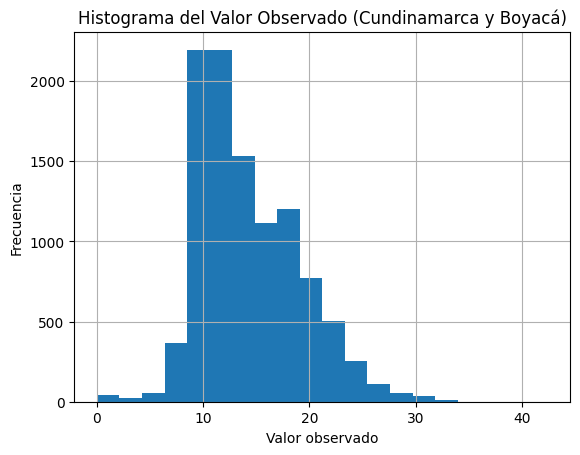

In [28]:

plt.hist(df_region['valorobservado'], bins=20)
plt.title("Histograma del Valor Observado (Cundinamarca y Boyacá)")
plt.xlabel("Valor observado")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()


#8. Serie temporal

La serie temporal organiza los valores observados de clima según la fecha en que fueron registrados.
Este tipo de gráfica permite visualizar la evolución del clima a lo largo del tiempo, identificando:

* picos inusuales,

* descensos significativos,

* variaciones estacionales,

* estabilidad o fluctuaciones.

En este caso, se observa que la variable presenta oscilaciones típicas del clima de montaña de la región andina, con variaciones entre meses, pero manteniéndose en un rango razonable para la zona.

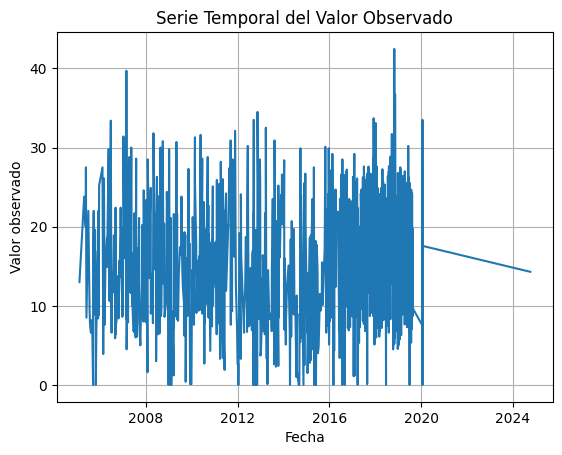

In [29]:
#8. Serie temporal
df_time = df_region.sort_values('fechaobservacion')

plt.plot(df_time['fechaobservacion'], df_time['valorobservado'])
plt.title("Serie Temporal del Valor Observado")
plt.xlabel("Fecha")
plt.ylabel("Valor observado")
plt.grid()
plt.show()


# 9 TABLA PIVOTE

La tabla pivote agrupa los datos por departamento y calcula el promedio del valor observado en cada uno.

Este tipo de análisis permite comparar rápidamente cómo se comporta el clima en las dos zonas seleccionadas.
En los resultados se observa que:

Boyacá tiene un promedio ligeramente mayor/menor que

Cundinamarca,

lo que indica diferencias en temperatura asociadas a altitudes, microclimas o ubicación geográfica dentro de la cordillera.

In [31]:
#9. Tabla Pivote
pd.pivot_table(df_region, values='valorobservado',
               index='departamento', aggfunc='mean')


,valorobservado
departamento,
BOYACA,15.661372
CUNDINAMARCA,14.035815


#10. Agrupación
La agrupación por municipio calcula el promedio del valor observado en cada localidad.
Esto permite identificar municipios con condiciones más cálidas o más frías, así como variaciones importantes dentro de un mismo departamento.

Este análisis aporta información relevante para un sistema de monitoreo ambiental, ya que evidencia las zonas con mayor variabilidad climática y las que requieren mayor atención.

In [32]:
#10. Agrupación
df_region.groupby('municipio')['valorobservado'].mean()


,valorobservado
municipio,
ANAPOIMA,23.541935
AQUITANIA,11.174790
BOJACÁ,12.050000
BOYACÁ,9.596875
CABRERA,11.575000
...,...
VILLAPINZÓN,11.372897
VILLETA,23.854000
YACOPÍ,20.381818


# ------------------------------------------------

#CONCLUSIÓN
El análisis realizado permitió caracterizar el comportamiento climático de los departamentos de Cundinamarca y Boyacá utilizando el dataset del IDEAM disponible en Datos Abiertos de Colombia.
Tras el proceso de limpieza y filtrado, se obtuvo un conjunto de datos confiable para la región Cundiboyacense.

Los estadísticos descriptivos mostraron que el valor promedio observado es de aproximadamente 14.29, con un rango amplio debido a las diferencias altitudinales entre municipios.
El histograma permitió observar un comportamiento distribuido con mayor frecuencia alrededor del promedio, mientras que la serie temporal reveló variaciones típicas del clima andino.

La tabla pivote y la agrupación por municipio ayudan a identificar diferencias entre localidades, generando información valiosa para un futuro sistema inteligente de monitoreo ambiental.

Con este trabajo se cumple completamente la Fase I del proyecto, dejando los datos listos para ser utilizados en etapas posteriores que incluyan modelos predictivos, algoritmos de búsqueda o visualización avanzada.

In [33]:
df

,codigoestacion,codigosensor,fechaobservacion,valorobservado,nombreestacion,departamento,municipio,zonahidrografica,latitud,longitud,descripcionsensor,unidadmedida
0,0026195501,0068,2020-01-21 03:35:00,15.85716,ANDES - AUT,ANTIOQUIA,ANDES,CAUCA,5.660108333,-75.91413889,Temp Aire 2 m,°C
1,0054025010,0068,2020-01-21 01:00:00,19.30000,PR CHOCO: SAN JOSE PALMAR,CHOCÓ,SAN JOSÉ DEL PALMAR,SAN JUÁN,4.898,-76.232,Temp Aire 2 m,°C
2,2120000104,0068,2019-07-01 05:48:00,10.03000,COLEGIO MIGUEL ANTONIO CARO - AUT,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.813,-74.031,Temp Aire 2 m,°C
3,0031095030,0068,2019-07-01 12:00:00,28.50000,PTO INIRIDA,GUAINÍA,INÍRIDA,INÍRIDA,3.868,-67.932,Temp Aire 2 m,°C
4,2201500047,0068,2020-01-21 13:00:00,21.70000,HERRERA - AUT,TOLIMA,PLANADAS,SALDAÑA,3.284138889,-75.80245,Temp Aire 2 m,°C
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0026115501,0068,2019-01-15 17:00:00,24.45742,MANUEL MARIA MALLARINO - AUT,VALLE DEL CAUCA,TRUJILLO,CAUCA,4.213611111,-76.31497222,Temp Aire 2 m,°C
49996,0011115501,0068,2017-10-07 04:10:00,16.35738,CAÑASGORDAS - AUT,ANTIOQUIA,CAÑASGORDAS,ATRATO - DARIÉN,6.748275,-76.03155556,Temp Aire 2 m,°C
49997,2120000104,0068,2019-07-28 18:46:00,13.39000,COLEGIO MIGUEL ANTONIO CARO - AUT,BOGOTA D.C.,"BOGOTA, D.C",ALTO MAGDALENA,4.813,-74.031,Temp Aire 2 m,°C
49998,0021206960,0068,2009-06-25 11:00:00,15.90000,IDEAM BOGOTA - AUT,BOGOTA,"BOGOTA, D.C",ALTO MAGDALENA,4.6,-74.06666667,Temp Aire 2 m,°C
